### Análisis Exploratorio de Datos — Comportamiento en eCommerce Retail
### **Objetivo:** Identificar patrones de comportamiento de usuarios,
### categorías con más compras y oportunidades de mejora en retención.
### **Herramientas:** Python, Pandas, Matplotlib, Seaborn
### **Autor:** Daniela Ducuara

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


print('Librerías cargadas')

Librerías cargadas


Cargar y explorar datos

In [2]:
df = pd.read_csv('C:/Users/Daniela/Proyecto_retail_EDA/data/2019-Oct.csv')

print(f" filas: {df.shape[0]:,}| columnas: {df.shape[1]}")
print(f"\n Tipos de datos: \n{df.dtypes}")
print(f"\n Primeras filas")
df.head()

 filas: 42,448,764| columnas: 9

 Tipos de datos: 
event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

 Primeras filas


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


Limpieza de datos

In [3]:
#Calcular nulos y validar que porcentaje representan  
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    "nulos": nulos,
    "porcentaje": porcentaje_nulos
})
resumen_nulos= resumen_nulos[resumen_nulos['nulos']>0]
resumen_nulos['porcentaje'] = resumen_nulos['porcentaje'].round(2)

resumen_nulos

,nulos,porcentaje
category_code,13515609,31.84
brand,6117080,14.41
user_session,2,0.00


In [4]:
# crear indicadores antes de reemplazar los nulos
df["sin_category_code"] = df["category_code"].isna()
df["sin_brand"] = df["brand"].isna()

# reemplazar nulos
df["category_code"] = df["category_code"].fillna("uncategorized")
df["brand"] = df["brand"].fillna("unbranded")

In [6]:
# Eliminar duplicados
duplicados = df.duplicated().sum()
print(f"\n Duplicados encontrados: {duplicados:,}")
df = df.drop_duplicates()


 Duplicados encontrados: 30,220


Las variables 'category_code' y 'brand' tenian una gran cantidad de valores nulos, pero según el metadato del dataset esto puede deberse a que la taxonomía de categoría solo estaría creada para categorías significativas y lo mismo para la marca indica que puede pasar desapercibida.
Por esta razón los valores nulos no se eliminaron y solo se renombraron como 'uncategorized' y 'unbranded' para no generar pérdida de información y evitar sesgos. 

In [7]:
#convertir a formato fecha 
df['event_time']=pd.to_datetime(df['event_time'], errors='coerce', utc=True)
df['fecha']=df['event_time'].dt.date
df['hora']= df['event_time'].dt.hour
df['dia_semana']= df['event_time'].dt.day_name()

#### ¿Qué hacen más los usuarios dentro del e-commerce? ¿ver productos, agregar al carrito o comprar?

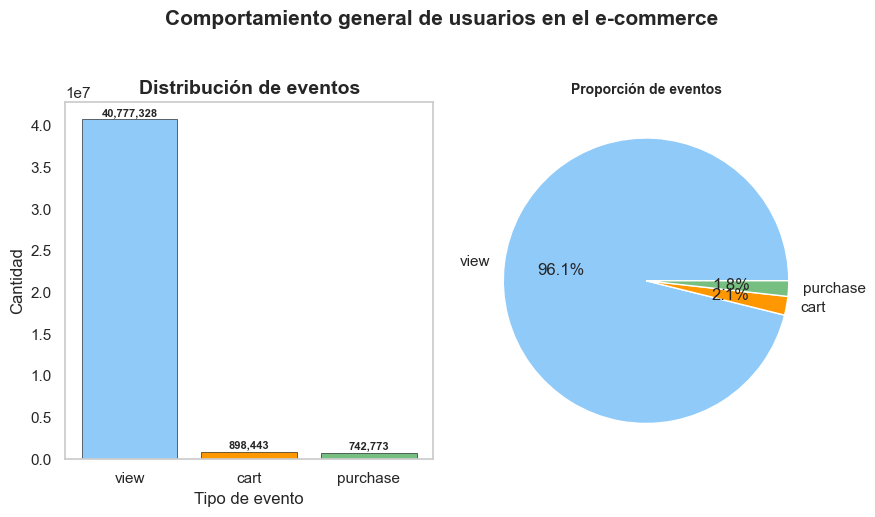


 Solo el 1.8% de interacciones terminan en compra


In [47]:

import matplotlib.pyplot as plt
conteo_eventos = df['event_type'].value_counts()

#grafico de barras 
fig, axes = plt.subplots(1, 2, figsize= (9,5))

fig.suptitle(
    'Comportamiento general de usuarios en el e-commerce',fontsize=15,fontweight='bold',y=1.03
)
axes[0].bar(conteo_eventos.index, conteo_eventos.values, color =['#90CAF9','#FF9800', '#77BF80'],     edgecolor="black",
    linewidth=0.4)
axes[0].set_title('Distribución de eventos', fontsize= 14, fontweight ='bold')
axes[0].set_xlabel('Tipo de evento')
axes[0].set_ylabel('Cantidad')
axes[0].grid(False)

for i, v in enumerate(conteo_eventos.values):
    axes[0].text(i, v +conteo_eventos.max() * 0.01, f'{v:,}', ha='center', fontweight='bold', fontsize=8,)

#gráfico de pastel 
axes[1].pie(conteo_eventos.values, labels= conteo_eventos.index,
            autopct='%1.1f%%', colors = ['#90CAF9', '#FF9800','#77BF80'])
axes[1].set_title('Proporción de eventos', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_distribucion_eventos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Solo el {conteo_eventos['purchase']/conteo_eventos.sum()*100:.1f}% de interacciones terminan en compra")

#### Tasa  de conversión por eventos

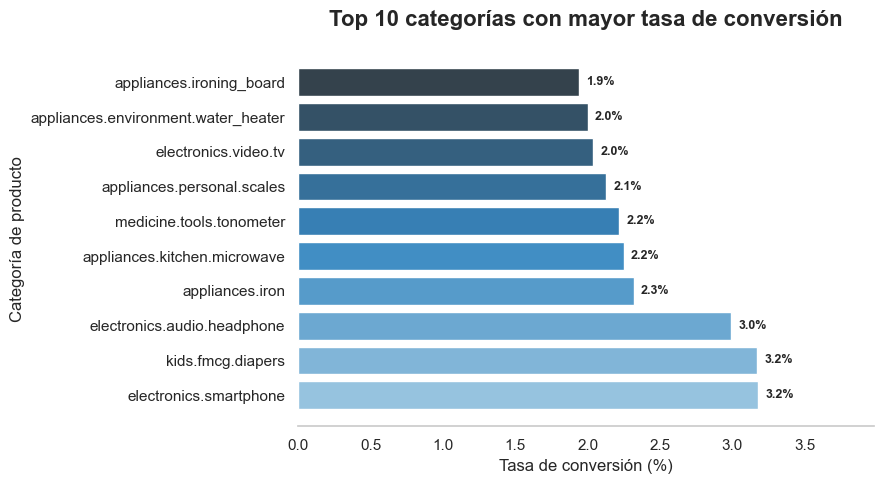

In [ ]:
#que categorías convierten mejor las vistas en compras 
conversion = df.groupby('category_code')['event_type'].value_counts().unstack(fill_value=0)

#calcular tasa de conversión si existen vistas y compras
if 'purchase' in conversion.columns and 'view' in conversion.columns:
    conversion['tasa_conversion']= (conversion['purchase']/conversion['view']*100).round(2)

#filtrar categoria
conversion_filtrada = conversion[conversion['view']>=1000]

#top 10 categorias con mayor tasa de conversión 
top_conversion = (
    conversion_filtrada["tasa_conversion"]
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(9, 5))
bars = plt.barh(
    top_conversion.index,top_conversion.values,
    color=sns.color_palette("Blues_d", len(top_conversion))
)

plt.title(
    "Top 10 categorías con mayor tasa de conversión",fontsize=16,fontweight="bold",pad=18
)

plt.xlabel("Tasa de conversión (%)", fontsize=12)
plt.ylabel("Categoría de producto", fontsize=12)


for bar, val in zip(bars, top_conversion.values):
    plt.text(
        val + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )
plt.xlim(0, top_conversion.max() + 0.8)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.grid(False)

plt.savefig(
    "../images/02_conversion_categorias.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

El análisis de conversión permite identificar cuales son las categorías que convierten en mayor proporción las visualizaciones en compras. Esto no quiere decir que estas categorías sean las mas vistas sino que, son las que en proporción a sus vistas,  tienen mayor tasa de compra. En otras palabras estas son las categorías que convierten el interes inicial del usuario en acción de compra. Como se puede observar en este caso la categoria para celulares y de productos infantiles (pañales), son las que mejor tienen tasa de conversión.

#### Categorías con mas compras

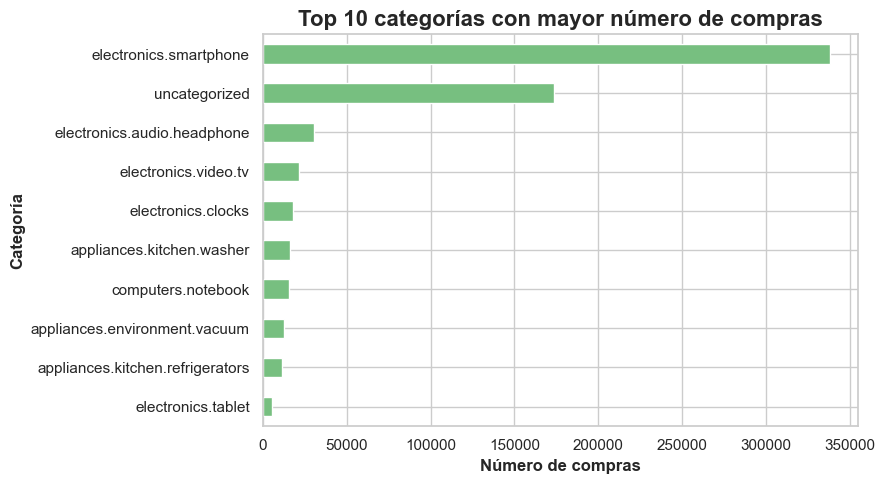

In [ ]:

compras_categoria = (
    df[df["event_type"] == "purchase"]
    .groupby("category_code")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
compras_categoria.sort_values().plot(kind="barh", color = '#77BF80')

plt.title("Top 10 categorías con mayor número de compras", fontsize=16, fontweight="bold")
plt.xlabel("Número de compras", fontweight = "bold")
plt.ylabel("Categoría", fontweight = "bold")
plt.tight_layout()
plt.savefig('../images/07_categorias_mayor_compras.png', dpi=150, bbox_inches='tight')

plt.show()

#### Comportamiento por hora del día

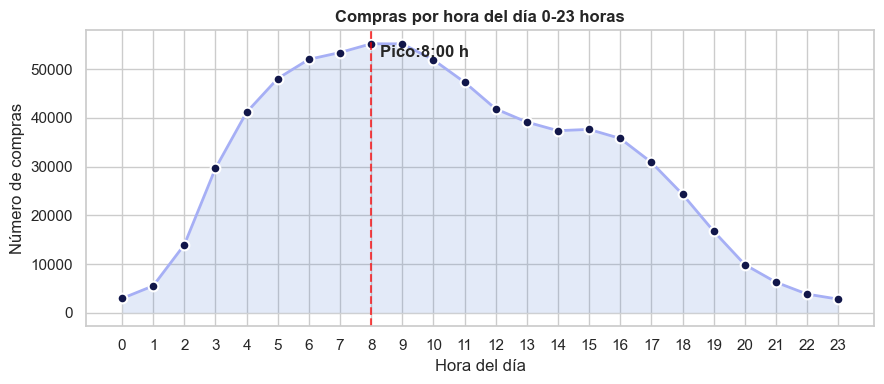

In [ ]:
#¿a que hora compran mas los usuarios ?
compras_hora = df[df['event_type']== 'purchase'].groupby('hora').size()

plt.figure(figsize=(9, 4))
plt.plot(compras_hora.index, compras_hora.values, marker='o', linewidth=2, markersize=7,     color='#A6AFF5',
    markerfacecolor='#12174A', markeredgecolor='white', markeredgewidth=1.5)

plt.fill_between(compras_hora.index, compras_hora.values, alpha = 0.15)

plt.title ('Compras por hora del día 0-23 horas', fontweight= 'bold')
plt.xlabel('Hora del día')
plt.ylabel('Número de compras')
plt.xticks(range(0, 24))
hora_pico = compras_hora.idxmax()
plt.axvline(x=hora_pico, color = 'red', linestyle= '--', alpha= 0.7)
plt.text(hora_pico +0.3, compras_hora.max()*0.95,
         f'Pico:{hora_pico}:00 h', fontweight= 'bold')

plt.tight_layout()
plt.savefig('../images/03_compras_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()

#### Mapa de calor día vs hora

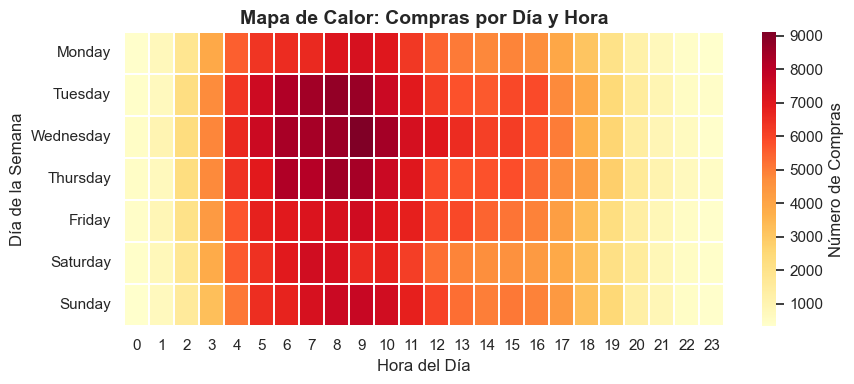

In [39]:
# ¿Qué día y hora hay más actividad?
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = df[df['event_type'] == 'purchase'].pivot_table(
    index='dia_semana', columns='hora',
    values='event_type', aggfunc='count'
).reindex(orden_dias)

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Número de Compras'})
plt.title('Mapa de Calor: Compras por Día y Hora', fontsize=14, fontweight='bold')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.tight_layout()
plt.savefig('../images/05_heatmap_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

#### ¿Cómo se distribuyen los precios de compra?, ¿existen valores atípicos que puedan afectar el análisis?

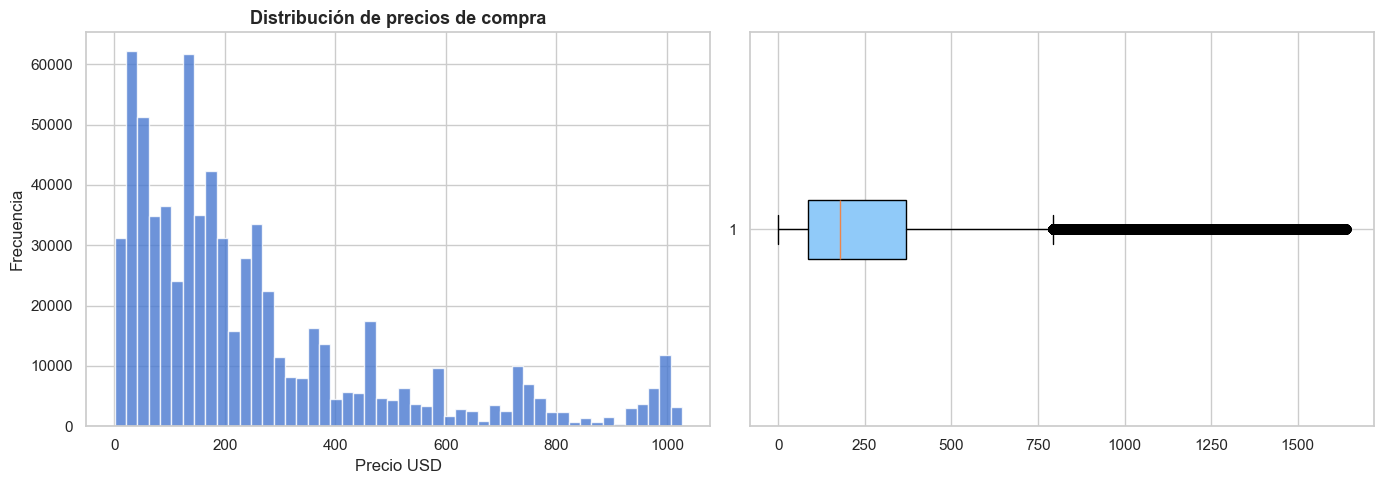

 Precio promedio: $309.56
 Precio mediana: $179.84
 Precio máximo: $2574.07


In [40]:
fig, axes= plt.subplots(1,2 ,figsize= (14,5))
compras = df[df['event_type']=='purchase']['price'].dropna()

#histograma
axes[0].hist(compras[compras<compras.quantile(0.95)], bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de precios de compra', fontsize = 13, fontweight='bold')
axes[0].set_xlabel('Precio USD')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(compras[compras< compras.quantile(0.99)], vert =False, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'))

plt.tight_layout()
plt.savefig('../images/04_distribucion_precios.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Precio promedio: ${compras.mean():.2f}")
print(f" Precio mediana: ${compras.median():.2f}")
print(f" Precio máximo: ${compras.max():.2f}")

La mayoría de transacciones se concentran en rangos bajos y medios. La distribución de los precios muestran una fuerte asimetría hacia la derecha ya que los precios muy altos generan que el promedio tenga un valor mucho mayor que el de la mediana.  

El boxplot confirma la presencia de múltiples valores atípicos superiores, los cuales se deben a que hay varios articulos con precios muy altos. Este hallazgo sugiere que, para analizar el precio típico de compra, la mediana y los percentiles son medidas más robustas que el promedio.

In [41]:
resumen_precios = pd.DataFrame({
    "medida": ["Q1", "Mediana", "Q3", "P90", "P95", "P99", "Máximo"],
    "precio": [
        compras.quantile(0.25),
        compras.quantile(0.50),
        compras.quantile(0.75),
        compras.quantile(0.90),
        compras.quantile(0.95),
        compras.quantile(0.99),
        compras.max()
    ]
})

resumen_precios["precio"] = resumen_precios["precio"].round(2)

resumen_precios

,medida,precio
0,Q1,87.49
1,Mediana,179.84
2,Q3,375.21
3,P90,782.22
4,P95,1027.05
5,P99,1639.82
6,Máximo,2574.07


El 50 % de las compras está por debajo de 179 dólares.
El 95 % de las compras está por debajo de 1027 dólares.

#### ingresos generados por categoría

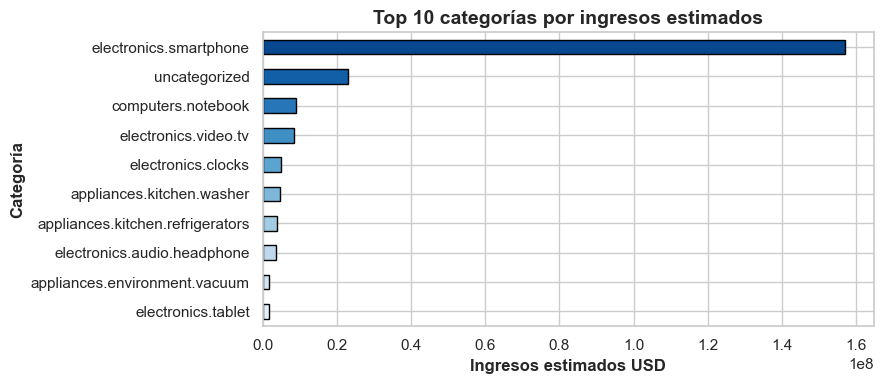

In [ ]:

ingresos_categoria = (
    df[df["event_type"] == "purchase"]
    .groupby("category_code")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 4))
ingresos_categoria.sort_values().plot(kind="barh", color=sns.color_palette("Blues", len(ingresos_categoria)), edgecolor="black",
    linewidth=1)

plt.title("Top 10 categorías por ingresos estimados", fontsize=14, fontweight="bold")
plt.xlabel("Ingresos estimados USD", fontweight = 'bold')
plt.ylabel("Categoría", fontweight = 'bold')

plt.tight_layout()
plt.savefig('../images/06_categoria_mayor_ingresos.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones del EDA

1. **Predominio de visualizaciones sobre compras:**  
   La mayor parte de las interacciones corresponde a eventos de visualización, lo que evidencia un comportamiento típico de navegación en e-commerce. Sin embargo, la distancia entre vistas, carritos y compras muestra una oportunidad de mejora en el embudo de conversión. Esto requiere fortalecer las páginas de producto, mejorar los llamados a la acción y reducir fricciones en el proceso de compra.

2. **Categorías con mejor eficiencia comercial:**  
   Categorías como electronics.smartphone, kids.fmcg.diapers y electronics.audio.headphone presentan mayores tasas de conversión relativa. Esto indcica que aunque no necesariamente sean las categorías con mayor volumen, sí convierten mejor las visualizaciones en compras. Estas categorías pueden ser priorizadas en inventario, campañas promocionales, estrategias de recomendación y acciones de remarketing.

3. **Patrones temporales de compra:**  
   El análisis por hora y el mapa de calor muestran que las compras no se distribuyen de forma uniforme durante el día ni durante la semana. Esto permite identificar franjas horarias estratégicas para campañas, promociones, descuentos o notificaciones.

4. **Distribución desigual de precios:**  
   Los precios de compra presentan una distribución asimétrica hacia la derecha, con presencia de valores atípicos altos. Estos outliers no necesariamente representan errores, sino productos de mayor valor que deberían analizarse por separado según categoría o segmento de precio.

5. **Valor estratégico del análisis:**  
   En síntesis, el análisis evidencia que el e-commerce presenta un alto volumen de navegación, pero una proporción reducida de compras, lo que revela oportunidades de optimización en el embudo de conversión. Las categorías con mejor desempeño relativo deben priorizarse en inventario, campañas y estrategias de recomendación. Además, los patrones de horarios de compra permiten orientar acciones comerciales en momentos de mayor actividad. 